In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Smart MCQ Solver Challenge 


### Project Overview

Multiple Choice Question (MCQ) answering is one of the most important tasks in Natural Language Processing (NLP). In this project, the objective is to develop machine learning or deep learning models capable of identifying the correct answer from five candidate options for each question.

Every question contains five possible answers (A-E), requiring the model to understand both the question and each answer option before ranking them according to their likelihood of being correct.

The project investigates three different modelling approaches:

- Traditional Machine Learning using TF-IDF with Logistic Regression and XGBoost
- Transformer-based Deep Learning using DeBERTa
- Scratch Deep Learning implementation using a BiLSTM network

Each approach is trained, evaluated, compared, and analyzed using a common evaluation framework before selecting the best-performing model for final competition submission.

---

### Objectives

The objectives of this project are:

- Perform comprehensive exploratory data analysis.
- Design an effective preprocessing pipeline.
- Build multiple machine learning and deep learning models.
- Compare different modelling strategies using identical evaluation metrics.
- Track experiments using Weights & Biases (W&B).
- Select the best model based on validation performance and Kaggle leaderboard score.
- Generate the final competition submission file.

---

### Project Workflow

```
                Dataset
                    │
       Exploratory Data Analysis
                    │
           Data Preprocessing
                    │
        ┌───────────┼───────────┐
        │           │           |
 Traditional ML   DeBERTa    Scratch BiLSTM
        │           │           │
        └───────────┼───────────┘
          Model Evaluation
                    |
          Model Comparison
                    |
         Best Model Selection
                    |   
          Kaggle Submission
```

In [2]:
import os
import re
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)


import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader


from transformers import *

import wandb

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


In [4]:
train = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
)

test = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
)

sample_submission = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"
)

print("Train Shape :", train.shape)
print("Test Shape :", test.shape)
print("Sample Submission Shape :", sample_submission.shape)

Train Shape : (2000, 8)
Test Shape : (500, 7)
Sample Submission Shape : (500, 2)


In [5]:
display(train.head())

display(test.head())

display(sample_submission.head())

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C


# EDA

In [6]:
print(train.info())
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ K

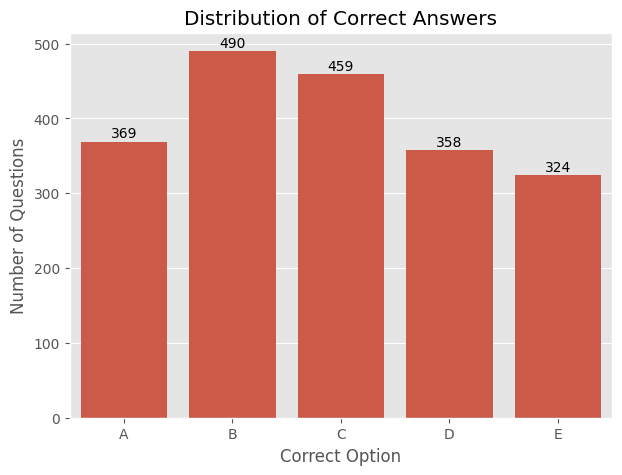

In [7]:
answer_counts = train["answer"].value_counts().sort_index()

plt.figure(figsize=(7,5))

sns.barplot(
    x=answer_counts.index,
    y=answer_counts.values
)

plt.title("Distribution of Correct Answers")

plt.xlabel("Correct Option")

plt.ylabel("Number of Questions")

for i,v in enumerate(answer_counts.values):
    plt.text(i,v+5,str(v),ha="center")

plt.show()

### Observation

The distribution of correct answers is relatively balanced across all five options.

Although minor variations exist, no single answer dominates the dataset. This balanced distribution reduces the risk of severe class imbalance and allows models to learn without requiring extensive class-weight adjustments.

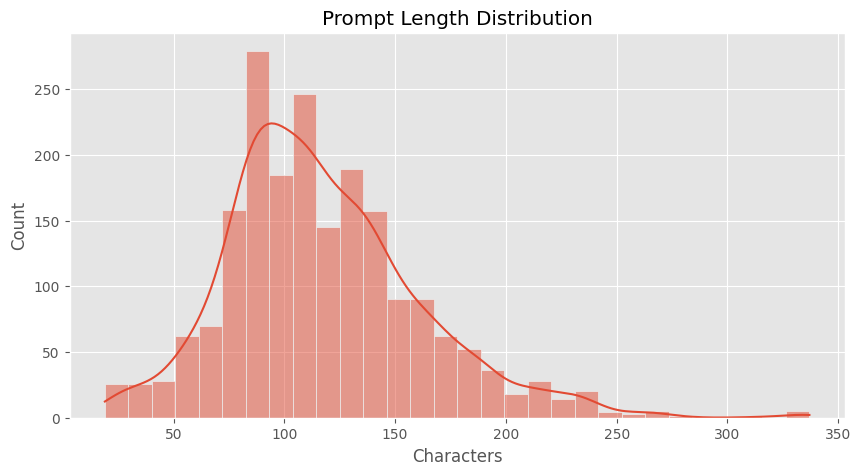

In [8]:
train["prompt_length"] = train["prompt"].str.len()

plt.figure(figsize=(10,5))

sns.histplot(
    train["prompt_length"],
    bins=30,
    kde=True
)

plt.title("Prompt Length Distribution")

plt.xlabel("Characters")

plt.show()

Question prompts exhibit varying lengths, ranging from short factual questions to long descriptive passages.

This variation suggests that deep learning models capable of handling long contextual information may outperform simpler bag-of-words approaches.

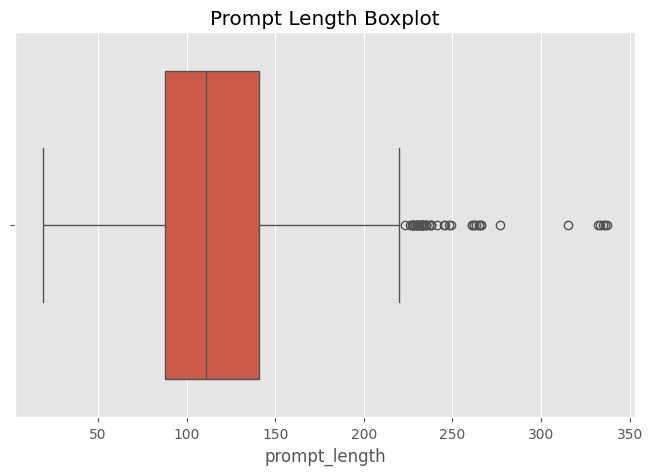

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=train["prompt_length"]
)

plt.title("Prompt Length Boxplot")

plt.show()

In [10]:
option_cols = ["A","B","C","D","E"]

option_length_df = pd.DataFrame()

for col in option_cols:
    option_length_df[col] = train[col].str.len()

option_length_df.head()

,A,B,C,D,E
0,307,258,222,202,191
1,406,364,365,407,408
2,12,11,9,9,9
3,307,258,222,202,191
4,230,233,233,99,99


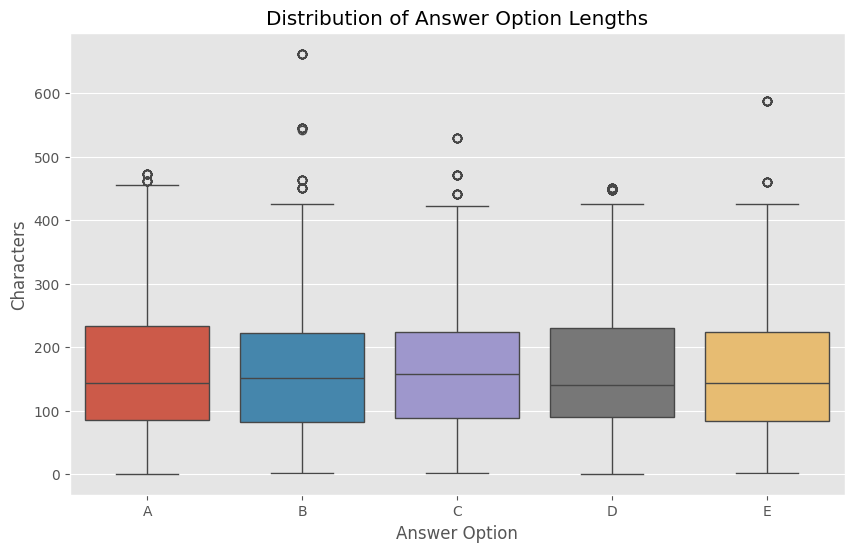

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(data=option_length_df)

plt.title("Distribution of Answer Option Lengths")

plt.xlabel("Answer Option")

plt.ylabel("Characters")

plt.show()


The answer options also vary considerably in length.

Many options contain detailed explanatory sentences rather than short phrases. This indicates that semantic understanding is essential, making transformer-based architectures particularly suitable for this task.

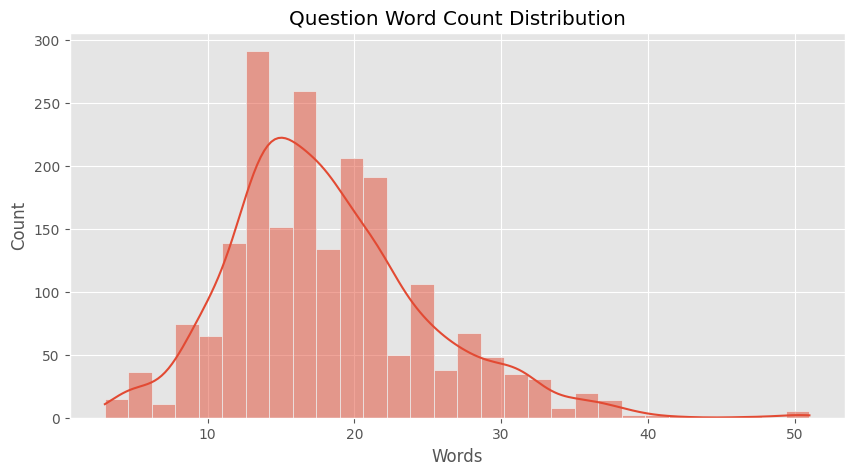

In [12]:
train["prompt_word_count"] = (
    train["prompt"]
    .str.split()
    .apply(len)
)

plt.figure(figsize=(10,5))

sns.histplot(
    train["prompt_word_count"],
    bins=30,
    kde=True
)

plt.title("Question Word Count Distribution")

plt.xlabel("Words")

plt.show()

In [13]:
statistics = pd.DataFrame({

"Minimum":[train["prompt_word_count"].min()],

"Average":[round(train["prompt_word_count"].mean(),2)],

"Median":[train["prompt_word_count"].median()],

"Maximum":[train["prompt_word_count"].max()]

})

statistics

,Minimum,Average,Median,Maximum
0,3,18.15,17.0,51


In [14]:
duplicate_prompts = train["prompt"].duplicated().sum()

duplicate_options = (

train[["A","B","C","D","E"]]

.duplicated()

.sum()

)

duplicates = pd.DataFrame({

"Feature":["Duplicate Questions",

"Duplicate Option Sets"],

"Count":[duplicate_prompts,

duplicate_options]

})

duplicates

,Feature,Count
0,Duplicate Questions,242
1,Duplicate Option Sets,1412


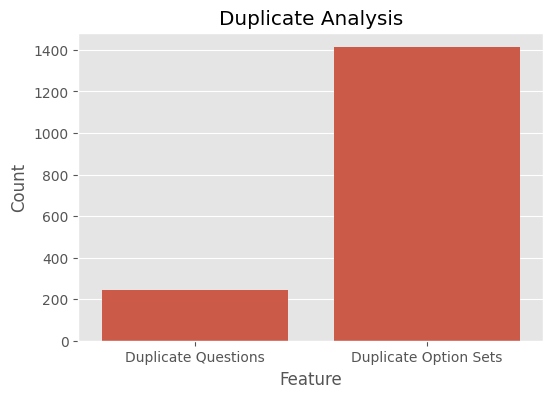

In [15]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=duplicates,
    x="Feature",
    y="Count"
)

plt.title("Duplicate Analysis")

plt.show()

In [16]:
instruction_phrases = [

"Pick the best possible answer:",

"Determine the correct option:",

"Select the most accurate option:",

"Identify the correct statement:",

"Choose the correct answer:",

"Which of the following is correct?"

]

def clean_prompt(prompt):

    prompt = str(prompt)

    for phrase in instruction_phrases:

        prompt = prompt.replace(phrase, "")

    return prompt.strip().lower()

train["clean_prompt"] = train["prompt"].apply(clean_prompt)

duplicate_clean = train["clean_prompt"].duplicated().sum()

duplicate_original = train["prompt"].duplicated().sum()

print("Original Prompt Duplicates :", duplicate_original)

print("Semantic Prompt Duplicates :", duplicate_clean)

Original Prompt Duplicates : 242
Semantic Prompt Duplicates : 1074


In [17]:
duplicate_df = pd.DataFrame({

"Duplicate Type":[

"Original Prompt",

"Cleaned Prompt"

],

"Count":[

duplicate_original,

duplicate_clean

]

})

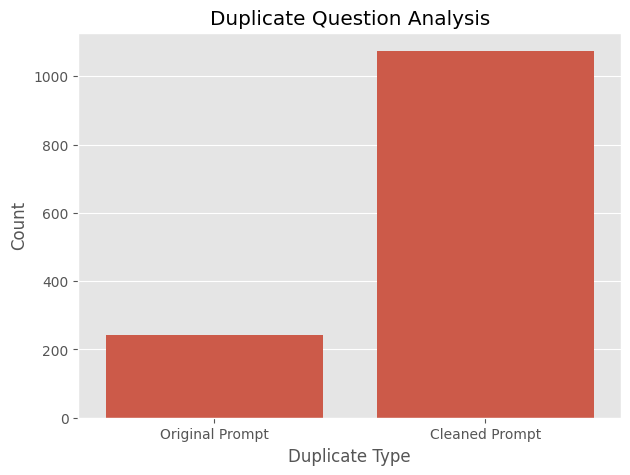

In [18]:
plt.figure(figsize=(7,5))

sns.barplot(

data=duplicate_df,

x="Duplicate Type",

y="Count"

)

plt.title("Duplicate Question Analysis")

plt.show()

To prevent information leakage during training, GroupShuffleSplit is later applied so that similar questions remain within the same dataset split

In [19]:
eda_stats = pd.DataFrame({

"Metric":[

"Train Samples",

"Test Samples",

"Duplicate Questions",

"Average Prompt Length (Characters)",

"Average Prompt Length (Words)",

"Maximum Prompt Length (Words)"

],

"Value":[

len(train),

len(test),

duplicate_clean,

round(train["prompt_length"].mean(),2),

round(train["prompt_word_count"].mean(),2),

train["prompt_word_count"].max()

]

})

eda_stats

,Metric,Value
0,Train Samples,2000.00
1,Test Samples,500.00
2,Duplicate Questions,1074.00
3,Average Prompt Length (Characters),117.67
4,Average Prompt Length (Words),18.15
5,Maximum Prompt Length (Words),51.00


# Data Preprocessing

Before model training, the dataset is transformed into appropriate numerical representations.

Although all three models solve the same task, they require different preprocessing pipelines due to differences in their underlying architectures.

To ensure a fair comparison, all models use the same train-validation split generated using GroupShuffleSplit, preventing data leakage caused by duplicate questions.

In [20]:
def create_ranking_dataset(df):

    rows = []

    option_columns = ["A","B","C","D","E"]

    for _, row in tqdm(df.iterrows(), total=len(df)):

        for option in option_columns:

            rows.append({

                "question_id": row["id"],

                "option": option,

                "text": (
                    "Question: "
                    + str(row["prompt"])
                    + " [SEP] Option: "
                    + str(row[option])
                ),

                "label": int(option == row["answer"])

            })

    return pd.DataFrame(rows)

In [21]:
ranking_df = create_ranking_dataset(train)

print("Ranking Dataset Shape:", ranking_df.shape)

ranking_df.head(10)

  0%|          | 0/2000 [00:00<?, ?it/s]

Ranking Dataset Shape: (10000, 4)


,question_id,option,text,label
0,1,A,Question: Pick the best possible answer: What ...,0
1,1,B,Question: Pick the best possible answer: What ...,1
2,1,C,Question: Pick the best possible answer: What ...,0
3,1,D,Question: Pick the best possible answer: What ...,0
4,1,E,Question: Pick the best possible answer: What ...,0
5,2,A,Question: What is accelerator-based light-ion ...,1
6,2,B,Question: What is accelerator-based light-ion ...,0
7,2,C,Question: What is accelerator-based light-ion ...,0
8,2,D,Question: What is accelerator-based light-ion ...,0
9,2,E,Question: What is accelerator-based light-ion ...,0


In [22]:
ranking_df["label"].value_counts()

label
0    8000
1    2000
Name: count, dtype: int64

## Train-Validation Split

groupshufflesplit keep the the option of each question on one side either on the validtion side or on the training side

In [23]:
splitter = GroupShuffleSplit(
    test_size=0.2,
    random_state=SEED
)

train_idx, val_idx = next(

    splitter.split(

        ranking_df,

        groups=ranking_df["question_id"]

    )

)

train_df = ranking_df.iloc[train_idx].reset_index(drop=True)

val_df = ranking_df.iloc[val_idx].reset_index(drop=True)

In [24]:
print("Training Samples :", train_df.shape)

print("Validation Samples :", val_df.shape)

Training Samples : (8000, 4)
Validation Samples : (2000, 4)


# MODEL1 - Traditional ML model (logistic regression + XgBoost)


The first modelling approach uses a classical Natural Language Processing pipeline.

the textual input is transformed into sparse TF-IDF vectors that represent the importance of words and phrases.

Two different classifiers are trained independently:

- Logistic Regression
- XGBoost

Finally, their prediction probabilities are combined using an ensemble strategy to improve robustness.


In [26]:
# wandb.finish()

In [27]:
# os.environ["WANDB_API_KEY"] = "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"
# wandb.init(

#     project="24f1002360-t22026",

#     name="traditional_ml_tfidf",

#     tags=[
#         "traditional-ml",
#         "tfidf",
#         "logistic-regression",
#         "xgboost"
#     ],

#     config={

#         "model":"Traditional ML",

#         "feature_extractor":"TF-IDF",

#         "max_features":30000,

#         "ngram_range":"(1,2)",

#         "sublinear_tf":True,

#         "min_df":2,

#         "max_df":0.95,

#         "logistic_C":2,

#         "logistic_max_iter":1000,

#         "xgb_estimators":300,

#         "xgb_learning_rate":0.05,

#         "xgb_max_depth":6,

#         "validation_split":"GroupShuffleSplit"

#     }

# )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: 24f1002360 (24f1002360-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### train validation split and ifidf vectorization

In [28]:
# X_train_text = train_df["text"]

# X_valid_text = val_df["text"]

# y_train = train_df["label"]

# y_valid = val_df["label"]

In [29]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(

#     lowercase=True,

#     stop_words="english",

#     max_features=30000,

#     ngram_range=(1,2),

#     sublinear_tf=True,

#     min_df=2,

#     max_df=0.95

# )

In [30]:
# X_train = tfidf.fit_transform(X_train_text)

# X_valid = tfidf.transform(X_valid_text)

# print("Training Feature Matrix :", X_train.shape)

# print("Validation Feature Matrix :", X_valid.shape)

Training Feature Matrix : (8000, 11161)
Validation Feature Matrix : (2000, 11161)


### Logistic Regression 
( to capture linear separability in sparse vectors)

In [31]:
# from sklearn.linear_model import LogisticRegression
# start_time = time.time()

# lr = LogisticRegression(

#     max_iter=1000,

#     C=2,

#     random_state=SEED,

#     n_jobs=-1

# )

# lr.fit(

#     X_train,

#     y_train

# )

# lr_training_time = time.time() - start_time

# print(f"Training Time : {lr_training_time:.2f} seconds")

Training Time : 1.95 seconds


In [32]:
# print("Logistic Regression Model")
# print(lr)

Logistic Regression Model
LogisticRegression(C=2, max_iter=1000, n_jobs=-1, random_state=42)


In [33]:
# valid_pred = lr.predict(X_valid)
# valid_prob = lr.predict_proba(X_valid)[:, 1]

In [34]:
# accuracy = accuracy_score(
#     y_valid,
#     valid_pred
# )

# precision = precision_score(
#     y_valid,
#     valid_pred,
#     zero_division=0
# )

# recall = recall_score(
#     y_valid,
#     valid_pred,
#     zero_division=0
# )

# f1 = f1_score(
#     y_valid,
#     valid_pred,
#     zero_division=0
# )


# print("Logistic Regression Validation Metrics")


# print(f"Accuracy  : {accuracy:.4f}")
# print(f"Precision : {precision:.4f}")
# print(f"Recall    : {recall:.4f}")
# print(f"F1 Score  : {f1:.4f}")

# print("\nClassification Report\n")

# print(
#     classification_report(
#         y_valid,
#         valid_pred,
#         zero_division=0
#     )
# )

Logistic Regression Validation Metrics
Accuracy  : 0.8990
Precision : 1.0000
Recall    : 0.4950
F1 Score  : 0.6622

Classification Report

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1600
           1       1.00      0.49      0.66       400

    accuracy                           0.90      2000
   macro avg       0.94      0.75      0.80      2000
weighted avg       0.91      0.90      0.88      2000



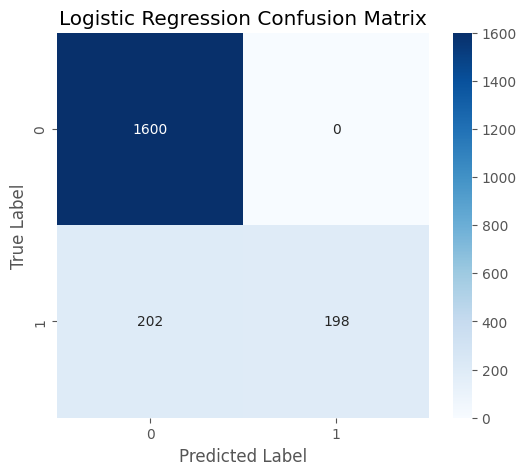

In [35]:

# cm = confusion_matrix(
#     y_valid,
#     valid_pred
# )

# plt.figure(figsize=(6,5))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Blues"
# )

# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Logistic Regression Confusion Matrix")

# plt.show()

In [36]:
# def apk(actual, predicted, k=3):

#     if len(predicted) > k:
#         predicted = predicted[:k]

#     score = 0.0
#     num_hits = 0.0

#     for i, p in enumerate(predicted):

#         if p == actual and p not in predicted[:i]:

#             num_hits += 1.0

#             score += num_hits / (i + 1)

#     return score


# def mapk(actuals, predictions, k=3):

#     return np.mean([
#         apk(a, p, k)
#         for a, p in zip(actuals, predictions)
#     ])

In [37]:
# valid_results = val_df.copy()

# valid_results["score"] = valid_prob

# predictions = []
# ground_truth = []

# for qid, group in valid_results.groupby("question_id"):

#     group = group.sort_values(
#         "score",
#         ascending=False
#     )

#     predictions.append(
#         group["option"].tolist()
#     )

#     ground_truth.append(
#         group.loc[
#             group["label"] == 1,
#             "option"
#         ].iloc[0]
#     )

# map3 = mapk(
#     ground_truth,
#     predictions,
#     k=3
# )

# print(f"Validation MAP@3 : {map3:.5f}")

Validation MAP@3 : 0.97417


In [38]:
# wandb.log({

#     "validation/accuracy": accuracy,
#     "validation/precision": precision,
#     "validation/recall": recall,
#     "validation/f1": f1,
#     "validation/map3": map3,

#     "training/time": lr_training_time,

#     "tfidf/vocabulary_size": len(tfidf.vocabulary_),
#     "tfidf/features": X_train.shape[1],

#     "dataset/train_samples": len(train_df),
#     "dataset/validation_samples": len(val_df),

#     "dataset/positive_samples": int(y_train.sum()),
#     "dataset/negative_samples": int(len(y_train)-y_train.sum())

# })

In [39]:
# lr_results = pd.DataFrame({

#     "Metric":[
#         "Accuracy",
#         "Precision",
#         "Recall",
#         "F1 Score",
#         "MAP@3",
#         "Training Time (sec)"
#     ],

#     "Value":[
#         accuracy,
#         precision,
#         recall,
#         f1,
#         map3,
#         lr_training_time
#     ]

# })

# display(lr_results)

,Metric,Value
0,Accuracy,0.899000
1,Precision,1.000000
2,Recall,0.495000
3,F1 Score,0.662207
4,MAP@3,0.974167
5,Training Time (sec),1.953413


### XgBoost
( to capture non-linear interaction between ifidf features)

In [40]:
# from xgboost import XGBClassifier
# start_time = time.time()

# xgb = XGBClassifier(

#     objective="binary:logistic",

#     eval_metric="logloss",

#     n_estimators=300,

#     learning_rate=0.05,

#     max_depth=6,

#     subsample=0.8,

#     colsample_bytree=0.8,

#     random_state=SEED,

#     n_jobs=-1

# )

# xgb.fit(

#     X_train,

#     y_train

# )

# xgb_training_time = time.time() - start_time

# print(f"Training Time : {xgb_training_time:.2f} seconds")

Training Time : 18.89 seconds


In [41]:
# print("XGBoost Model")
# print(xgb)

XGBoost Model
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [42]:
# training_summary = pd.DataFrame({

# "Model":[

# "Logistic Regression",

# "XGBoost"

# ],

# "Training Time (sec)":[

# round(lr_training_time,2),

# round(xgb_training_time,2)

# ]

# })

# training_summary

,Model,Training Time (sec)
0,Logistic Regression,1.95
1,XGBoost,18.89


In [43]:
# xgb_pred = xgb.predict(X_valid)

# xgb_prob = xgb.predict_proba(X_valid)[:,1]

In [44]:
# xgb_accuracy = accuracy_score(
#     y_valid,
#     xgb_pred
# )

# xgb_precision = precision_score(
#     y_valid,
#     xgb_pred,
#     zero_division=0
# )

# xgb_recall = recall_score(
#     y_valid,
#     xgb_pred,
#     zero_division=0
# )

# xgb_f1 = f1_score(
#     y_valid,
#     xgb_pred,
#     zero_division=0
# )


# print("XGBoost Validation Metrics")


# print(f"Accuracy  : {xgb_accuracy:.4f}")
# print(f"Precision : {xgb_precision:.4f}")
# print(f"Recall    : {xgb_recall:.4f}")
# print(f"F1 Score  : {xgb_f1:.4f}")

# print()

# print(classification_report(
#     y_valid,
#     xgb_pred,
#     zero_division=0
# ))

XGBoost Validation Metrics
Accuracy  : 0.8795
Precision : 0.9818
Recall    : 0.4050
F1 Score  : 0.5735

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1600
           1       0.98      0.41      0.57       400

    accuracy                           0.88      2000
   macro avg       0.93      0.70      0.75      2000
weighted avg       0.89      0.88      0.86      2000



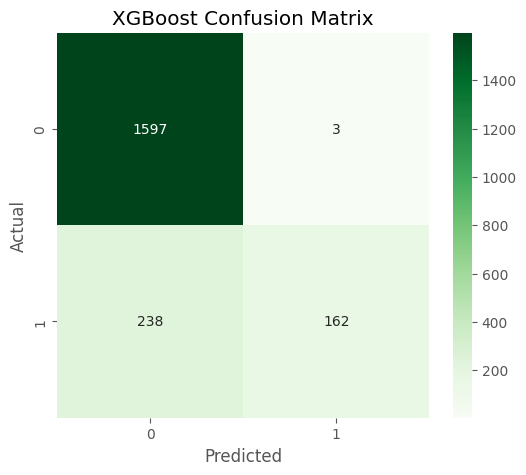

In [45]:
# cm = confusion_matrix(
#     y_valid,
#     xgb_pred
# )

# plt.figure(figsize=(6,5))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Greens"
# )

# plt.title("XGBoost Confusion Matrix")

# plt.xlabel("Predicted")

# plt.ylabel("Actual")

# plt.show()

In [46]:
# valid_results = val_df.copy()

# valid_results["score"] = xgb_prob

# predictions = []

# ground_truth = []

# for qid, group in valid_results.groupby("question_id"):

#     group = group.sort_values(
#         "score",
#         ascending=False
#     )

#     predictions.append(
#         group["option"].tolist()
#     )

#     ground_truth.append(
#         group.loc[
#             group["label"]==1,
#             "option"
#         ].iloc[0]
#     )

# xgb_map3 = mapk(
#     ground_truth,
#     predictions,
#     k=3
# )

# print(f"Validation MAP@3 : {xgb_map3:.5f}")

Validation MAP@3 : 0.93417


In [47]:
# wandb.log({


#     "validation/accuracy": xgb_accuracy,
#     "validation/precision": xgb_precision,
#     "validation/recall": xgb_recall,
#     "validation/f1": xgb_f1,
#     "validation/map3": xgb_map3,


#     "training/time": xgb_training_time,

#     "tfidf/vocabulary_size": len(tfidf.vocabulary_),
#     "tfidf/features": X_train.shape[1],


#     "dataset/train_samples": len(train_df),
#     "dataset/validation_samples": len(val_df),

#     "dataset/positive_samples": int(y_train.sum()),
#     "dataset/negative_samples": int(len(y_train) - y_train.sum())

# })

In [48]:
# xgb_results = pd.DataFrame({

#     "Metric":[

#         "Accuracy",

#         "Precision",

#         "Recall",

#         "F1 Score",

#         "MAP@3",

#         "Training Time (sec)"

#     ],

#     "Value":[

#         xgb_accuracy,

#         xgb_precision,

#         xgb_recall,

#         xgb_f1,

#         xgb_map3,

#         xgb_training_time

#     ]

# })

# display(xgb_results)

,Metric,Value
0,Accuracy,0.879500
1,Precision,0.981818
2,Recall,0.405000
3,F1 Score,0.573451
4,MAP@3,0.934167
5,Training Time (sec),18.887957


### Ensemble 
(soft voting)

In [49]:
# ensemble_prob = (valid_prob + xgb_prob) / 2

# ensemble_pred = (ensemble_prob >= 0.5).astype(int)

In [50]:
# ensemble_accuracy = accuracy_score(
#     y_valid,
#     ensemble_pred
# )

# ensemble_precision = precision_score(
#     y_valid,
#     ensemble_pred,
#     zero_division=0
# )

# ensemble_recall = recall_score(
#     y_valid,
#     ensemble_pred,
#     zero_division=0
# )

# ensemble_f1 = f1_score(
#     y_valid,
#     ensemble_pred,
#     zero_division=0
# )


# print("Ensemble Validation Metrics")


# print(f"Accuracy  : {ensemble_accuracy:.4f}")
# print(f"Precision : {ensemble_precision:.4f}")
# print(f"Recall    : {ensemble_recall:.4f}")
# print(f"F1 Score  : {ensemble_f1:.4f}")

# print()

# print(
#     classification_report(
#         y_valid,
#         ensemble_pred,
#         zero_division=0
#     )
# )

Ensemble Validation Metrics
Accuracy  : 0.8885
Precision : 1.0000
Recall    : 0.4425
F1 Score  : 0.6135

              precision    recall  f1-score   support

           0       0.88      1.00      0.93      1600
           1       1.00      0.44      0.61       400

    accuracy                           0.89      2000
   macro avg       0.94      0.72      0.77      2000
weighted avg       0.90      0.89      0.87      2000



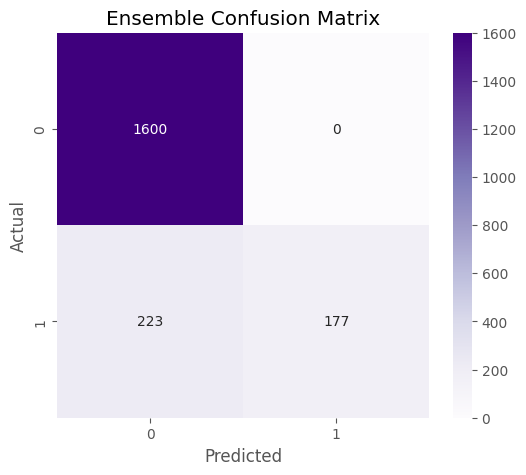

In [51]:
# cm = confusion_matrix(
#     y_valid,
#     ensemble_pred
# )

# plt.figure(figsize=(6,5))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Purples"
# )

# plt.title("Ensemble Confusion Matrix")

# plt.xlabel("Predicted")

# plt.ylabel("Actual")

# plt.show()

In [52]:
# valid_results = val_df.copy()

# valid_results["score"] = ensemble_prob

# predictions = []

# ground_truth = []

# for qid, group in valid_results.groupby("question_id"):

#     group = group.sort_values(
#         "score",
#         ascending=False
#     )

#     predictions.append(
#         group["option"].tolist()
#     )

#     ground_truth.append(
#         group.loc[
#             group["label"] == 1,
#             "option"
#         ].iloc[0]
#     )

# ensemble_map3 = mapk(
#     ground_truth,
#     predictions,
#     k=3
# )

# print(f"Validation MAP@3 : {ensemble_map3:.5f}")

Validation MAP@3 : 0.96792


In [53]:
# wandb.log({

#     "validation/accuracy": ensemble_accuracy,
#     "validation/precision": ensemble_precision,
#     "validation/recall": ensemble_recall,
#     "validation/f1": ensemble_f1,
#     "validation/map3": ensemble_map3,

#     "training/time": lr_training_time + xgb_training_time,

#     "tfidf/vocabulary_size": len(tfidf.vocabulary_),
#     "tfidf/features": X_train.shape[1],

#     "dataset/train_samples": len(train_df),
#     "dataset/validation_samples": len(val_df),

#     "dataset/positive_samples": int(y_train.sum()),
#     "dataset/negative_samples": int(len(y_train) - y_train.sum())

# })

In [54]:
# ensemble_results = pd.DataFrame({

#     "Metric":[
#         "Accuracy",
#         "Precision",
#         "Recall",
#         "F1 Score",
#         "MAP@3",
#         "Training Time (sec)"
#     ],

#     "Value":[
#         ensemble_accuracy,
#         ensemble_precision,
#         ensemble_recall,
#         ensemble_f1,
#         ensemble_map3,
#         lr_training_time + xgb_training_time
#     ]

# })

# display(ensemble_results)

,Metric,Value
0,Accuracy,0.888500
1,Precision,1.000000
2,Recall,0.442500
3,F1 Score,0.613518
4,MAP@3,0.967917
5,Training Time (sec),20.841371


### Comparison of lr , xgboost , and ensemble method

In [55]:
# comparison_df = pd.DataFrame({

#     "Model":[
#         "Logistic Regression",
#         "XGBoost",
#         "Ensemble"
#     ],

#     "Accuracy":[
#         accuracy,
#         xgb_accuracy,
#         ensemble_accuracy
#     ],

#     "Precision":[
#         precision,
#         xgb_precision,
#         ensemble_precision
#     ],

#     "Recall":[
#         recall,
#         xgb_recall,
#         ensemble_recall
#     ],

#     "F1 Score":[
#         f1,
#         xgb_f1,
#         ensemble_f1
#     ],

#     "MAP@3":[
#         map3,
#         xgb_map3,
#         ensemble_map3
#     ],

#     "Training Time (sec)":[
#         lr_training_time,
#         xgb_training_time,
#         lr_training_time + xgb_training_time
#     ]

# })

# comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,MAP@3,Training Time (sec)
0,Logistic Regression,0.8990,1.000000,0.4950,0.662207,0.974167,1.953413
1,XGBoost,0.8795,0.981818,0.4050,0.573451,0.934167,18.887957
2,Ensemble,0.8885,1.000000,0.4425,0.613518,0.967917,20.841371


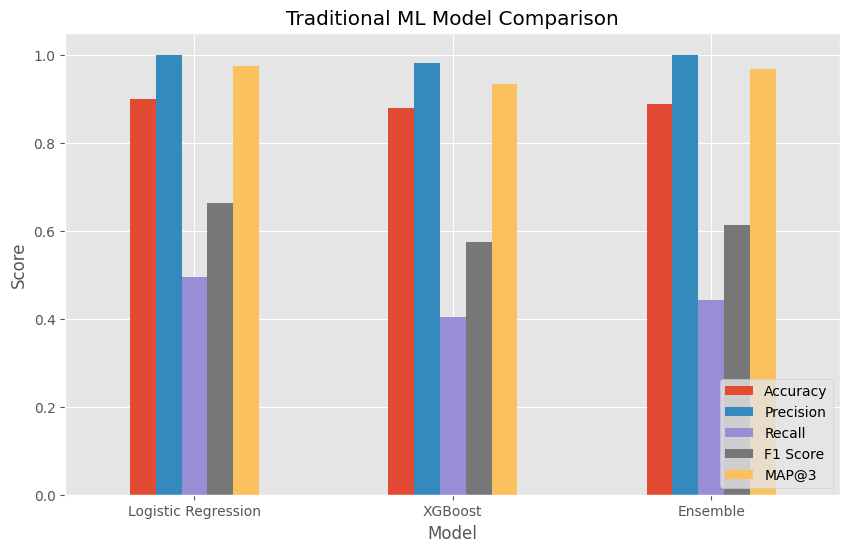

In [56]:
# metrics = [
#     "Accuracy",
#     "Precision",
#     "Recall",
#     "F1 Score",
#     "MAP@3"
# ]

# comparison_df.set_index("Model")[metrics].plot(
#     kind="bar",
#     figsize=(10,6)
# )

# plt.title("Traditional ML Model Comparison")

# plt.ylabel("Score")

# plt.xticks(rotation=0)

# plt.legend(loc="lower right")

# plt.show()

In [57]:
# best_ml_model = comparison_df.loc[
#     comparison_df["MAP@3"].idxmax()
# ]


# print("Best Traditional ML Model")
# display(best_ml_model)

Best Traditional ML Model


Model                  Logistic Regression
Accuracy                             0.899
Precision                              1.0
Recall                               0.495
F1 Score                          0.662207
MAP@3                             0.974167
Training Time (sec)               1.953413
Name: 0, dtype: object

In [58]:
# wandb.summary["best_traditional_model"] = best_ml_model["Model"]
# wandb.summary["best_traditional_map3"] = comparison_df["MAP@3"].max()
# wandb.summary["traditional_models_evaluated"] = 3

# wandb.finish()

dataset/negative_samples,▁▁▁
dataset/positive_samples,▁▁▁
dataset/train_samples,▁▁▁
dataset/validation_samples,▁▁▁
tfidf/features,▁▁▁
tfidf/vocabulary_size,▁▁▁
training/time,▁▇█
validation/accuracy,█▁▄
validation/f1,█▁▄
validation/map3,█▁▇
+2,...


# MODEL2 - DeBERTa optimaization

In [59]:
# os.environ["WANDB_API_KEY"] = "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"
# wandb.init(

#     project="24f1002360-t22026",

#     name="deberta_v3_base",

#     tags=[

#         "transformer",

#         "deberta-v3",

#         "huggingface",

#         "sequence-classification"

#     ],

#     config={

#         "model":"microsoft/deberta-v3-base",

#         "architecture":"Transformer",

#         "max_length":256,

#         "epochs":4,

#         "batch_size":8,

#         "learning_rate":1e-5,

#         "weight_decay":0.01,

#         "optimizer":"AdamW",

#         "scheduler":"Linear",

#         "validation_split":"GroupShuffleSplit",

#         "early_stopping_patience":3

#     }

# )

### dataset convert to hugging face dataset 

In [60]:
# from datasets import Dataset

# train_dataset = Dataset.from_pandas(
#     train_df.reset_index(drop=True)
# )

# valid_dataset = Dataset.from_pandas(
#     val_df.reset_index(drop=True)
# )

# print(train_dataset)
# print(valid_dataset)

Dataset({
    features: ['question_id', 'option', 'text', 'label'],
    num_rows: 8000
})
Dataset({
    features: ['question_id', 'option', 'text', 'label'],
    num_rows: 2000
})


### load tokenizer

In [61]:
# from transformers import AutoTokenizer

# MODEL_NAME = "microsoft/deberta-v3-base"

# tokenizer = AutoTokenizer.from_pretrained(
#     MODEL_NAME
# )

# MAX_LEN = 256

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--microsoft--deberta-v3-base/snapshots/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json
Model config DebertaV2Config {
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-07,
  "legacy": true,
  "max_position_embeddings": 512,
  "max_relative_positions": -1,
  "model_type": "deberta-v2",
  "norm_rel_ebd": "layer_norm",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_dropout": 0,
  "pooler_hidden_act": "gelu",
  "pooler_hidden_size": 768,
  "pos_att_type": [
    "p2c",
    "c2p"
  ],
  "position_biased_input": false,
  "position_buckets": 256,
  "relative_attention": true,
  "share_att_key": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [62]:
# def tokenize(batch):

#     return tokenizer(

#         batch["text"],

#         truncation=True,

#         padding="max_length",

#         max_length=MAX_LEN

#     )

In [63]:
# train_dataset = train_dataset.map(
#     tokenize,
#     batched=True
# )

# valid_dataset = valid_dataset.map(
#     tokenize,
#     batched=True
# )

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [64]:
# train_dataset.set_format(

#     type="torch",

#     columns=[

#         "input_ids",

#         "attention_mask",

#         "label"

#     ]

# )

# valid_dataset.set_format(

#     type="torch",

#     columns=[

#         "input_ids",

#         "attention_mask",

#         "label"

#     ]

# )

### Load model

In [65]:
# from transformers import AutoModelForSequenceClassification

# model = AutoModelForSequenceClassification.from_pretrained(
#     "microsoft/deberta-v3-base",
#     num_labels=2,
#     torch_dtype=torch.float32,
#     force_download=True
# )

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--microsoft--deberta-v3-base/snapshots/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json
`torch_dtype` is deprecated! Use `dtype` instead!
Model config DebertaV2Config {
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-07,
  "legacy": true,
  "max_position_embeddings": 512,
  "max_relative_positions": -1,
  "model_type": "deberta-v2",
  "norm_rel_ebd": "layer_norm",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_dropout": 0,
  "pooler_hidden_act": "gelu",
  "pooler_hidden_size": 768,
  "pos_att_type": [
    "p2c",
    "c2p"
  ],
  "position_biased_input": false,
  "position_buckets": 256,
  "relative_attention": true,
  "share_att_key": true,
 

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

loading weights file pytorch_model.bin from cache at /root/.cache/huggingface/hub/models--microsoft--deberta-v3-base/snapshots/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/pytorch_model.bin
Attempting to create safetensors variant


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Safetensors PR exists
DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
cla

In [66]:
# print("Model Summary")

# print(f"Model Name        : {MODEL_NAME}")
# print(f"Maximum Length    : {MAX_LEN}")
# print(f"Training Samples  : {len(train_dataset)}")
# print(f"Validation Samples: {len(valid_dataset)}")

Model Summary
Model Name        : microsoft/deberta-v3-base
Maximum Length    : 256
Training Samples  : 8000
Validation Samples: 2000


### eval metrices

In [67]:
# def compute_metrics(eval_pred):

#     logits, labels = eval_pred

#     predictions = np.argmax(
#         logits,
#         axis=-1
#     )

#     accuracy = accuracy_score(
#         labels,
#         predictions
#     )

#     precision = precision_score(
#         labels,
#         predictions,
#         zero_division=0
#     )

#     recall = recall_score(
#         labels,
#         predictions,
#         zero_division=0
#     )

#     f1 = f1_score(
#         labels,
#         predictions,
#         zero_division=0
#     )

#     return {

#         "accuracy": accuracy,

#         "precision": precision,

#         "recall": recall,

#         "f1": f1

#     }

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

In [68]:
# from transformers import (

#     TrainingArguments

# )

# training_args = TrainingArguments(

#     output_dir="./deberta_checkpoint",

#     do_train=True,

#     do_eval=True,

#     eval_strategy="epoch",

#     save_strategy="epoch",

#     logging_strategy="epoch",

#     num_train_epochs=4,

#     per_device_train_batch_size=8,

#     per_device_eval_batch_size=16,

#     learning_rate=1e-5,

#     weight_decay=0.01,

#     load_best_model_at_end=True,

#     metric_for_best_model="f1",

#     greater_is_better=True,

#     report_to="wandb",

#     seed=SEED,

#     fp16=False,
#     bf16=False,

# )

PyTorch: setting up devices


In [69]:
# from transformers import (

#     Trainer,

#     DataCollatorWithPadding,

#     EarlyStoppingCallback

# )

# trainer = Trainer(

#     model=model,

#     args=training_args,

#     train_dataset=train_dataset,

#     eval_dataset=valid_dataset,

#     data_collator=DataCollatorWithPadding(
#         tokenizer
#     ),

#     compute_metrics=compute_metrics,

#     callbacks=[

#         EarlyStoppingCallback(

#             early_stopping_patience=3

#         )

#     ]

# )

In [70]:
# import time

# start_time = time.time()

# trainer.train()

# deberta_training_time = time.time() - start_time

# print(f"Training Time : {deberta_training_time:.2f} seconds")

The following columns in the Training set don't have a corresponding argument in `DebertaV2ForSequenceClassification.forward` and have been ignored: question_id, option, text. If question_id, option, text are not expected by `DebertaV2ForSequenceClassification.forward`,  you can safely ignore this message.
***** Running training *****
  Num examples = 8,000
  Num Epochs = 4
  Instantaneous batch size per device = 8
  Training with DataParallel so batch size has been adjusted to: 16
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 1
  Total optimization steps = 2,000
  Number of trainable parameters = 184,423,682


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.016359,0.976106,0.800000,0.000000,0.000000,0.000000
2,0.859777,0.595706,0.893500,0.926941,0.507500,0.655897
3,0.586947,0.448255,0.925500,0.984556,0.637500,0.773900
4,0.445814,0.336649,0.941500,0.960912,0.737500,0.834512


The following columns in the Evaluation set don't have a corresponding argument in `DebertaV2ForSequenceClassification.forward` and have been ignored: question_id, option, text. If question_id, option, text are not expected by `DebertaV2ForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2000
  Batch size = 32
Saving model checkpoint to ./deberta_checkpoint/checkpoint-500
Configuration saved in ./deberta_checkpoint/checkpoint-500/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in ./deberta_checkpoint/checkpoint-500/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in ./deberta_checkpoint/checkpoint-500/tokenizer_config.json
The following columns in the Evaluation set don't have a corresponding argument in `DebertaV2ForSequenceClassification.forward` and have been ignored: question_id, option, text. If question_id, option, text are not expected by `DebertaV2ForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2000
  Batch size = 32
Saving model checkpoint to ./deberta_checkpoint/checkpoint-1000
Configuration saved in ./deberta_checkpoint/checkpoint-1000/config.json


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in ./deberta_checkpoint/checkpoint-1500/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in ./deberta_checkpoint/checkpoint-1500/tokenizer_config.json
The following columns in the Evaluation set don't have a corresponding argument in `DebertaV2ForSequenceClassification.forward` and have been ignored: question_id, option, text. If question_id, option, text are not expected by `DebertaV2ForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2000
  Batch size = 32
Saving model checkpoint to ./deberta_checkpoint/checkpoint-2000
Configuration saved in ./deberta_checkpoint/checkpoint-2000/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in ./deberta_checkpoint/checkpoint-2000/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in ./deberta_checkpoint/checkpoint-2000/tokenizer_config.json


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from ./deberta_checkpoint/checkpoint-2000 (score: 0.8345120226308345).
There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bi

Training Time : 1419.65 seconds


### Validation 

In [71]:
# from scipy.special import softmax
# import numpy as np

# predictions = trainer.predict(valid_dataset)

# logits = predictions.predictions

# probabilities = softmax(
#     logits,
#     axis=1
# )

# predicted_labels = np.argmax(
#     probabilities,
#     axis=1
# )

# true_labels = np.array(
#     predictions.label_ids
# )

# print("Prediction Shape :", probabilities.shape)

The following columns in the test set don't have a corresponding argument in `DebertaV2ForSequenceClassification.forward` and have been ignored: question_id, option, text. If question_id, option, text are not expected by `DebertaV2ForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Prediction *****
  Num examples = 2000
  Batch size = 32


Prediction Shape : (2000, 2)


In [72]:
# deberta_accuracy = accuracy_score(
#     true_labels,
#     predicted_labels
# )

# deberta_precision = precision_score(
#     true_labels,
#     predicted_labels,
#     zero_division=0
# )

# deberta_recall = recall_score(
#     true_labels,
#     predicted_labels,
#     zero_division=0
# )

# deberta_f1 = f1_score(
#     true_labels,
#     predicted_labels,
#     zero_division=0
# )

# metrics_df = pd.DataFrame({

#     "Metric":[

#         "Accuracy",
#         "Precision",
#         "Recall",
#         "F1 Score"

#     ],

#     "Score":[

#         deberta_accuracy,
#         deberta_precision,
#         deberta_recall,
#         deberta_f1

#     ]

# })

# display(metrics_df)

,Metric,Score
0,Accuracy,0.941500
1,Precision,0.960912
2,Recall,0.737500
3,F1 Score,0.834512


In [73]:
# option_labels = ["A", "B", "C", "D", "E"]

# ranking_df = val_df.copy()

# ranking_df["probability"] = probabilities[:,1]

In [74]:
# top3_predictions = (
#     ranking_df
#     .groupby("question_id")
#     .apply(
#         lambda x:
#         x.sort_values(
#             "probability",
#             ascending=False
#         )["option"].head(3).tolist()
#     )
# )

# ground_truth = (
#     ranking_df
#     .groupby("question_id")
#     .apply(
#         lambda x:
#         x.loc[
#             x["label"]==1,
#             "option"
#         ].iloc[0]
#     )
# )

In [75]:
# def map3_score(
#     actual,
#     predicted

# ):
#     score = 0
#     for a,p in zip(
#         actual,
#         predicted

#     ):
#         if a in p:
#             score += 1/(p.index(a)+1)
#     return score/len(actual)

In [76]:
# deberta_map3 = map3_score(
#     ground_truth.tolist(),
#     top3_predictions.tolist()
# )
# print(f"Validation MAP@3 : {deberta_map3:.5f}")

Validation MAP@3 : 0.94875


In [77]:
# wandb.log({
#     "validation/accuracy": deberta_accuracy,
#     "validation/precision": deberta_precision,
#     "validation/recall": deberta_recall,
#     "validation/f1": deberta_f1,
#     "validation/map3": deberta_map3,
#     "training/time": deberta_training_time

# })

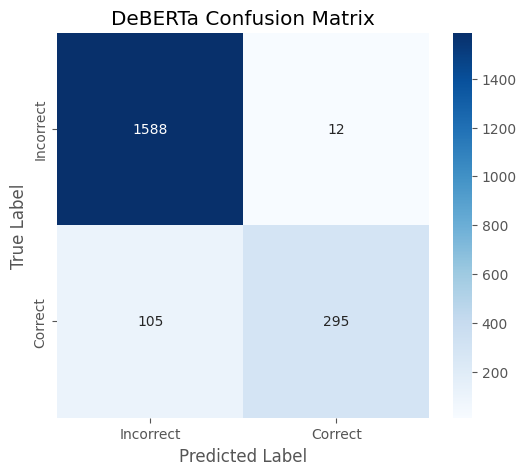

In [78]:
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# cm = confusion_matrix(

#     true_labels,

#     predicted_labels

# )

# plt.figure(figsize=(6,5))

# sns.heatmap(

#     cm,

#     annot=True,

#     fmt="d",

#     cmap="Blues",

#     xticklabels=["Incorrect","Correct"],

#     yticklabels=["Incorrect","Correct"]

# )

# plt.title("DeBERTa Confusion Matrix")

# plt.xlabel("Predicted Label")

# plt.ylabel("True Label")

# plt.show()

### ROC Curve

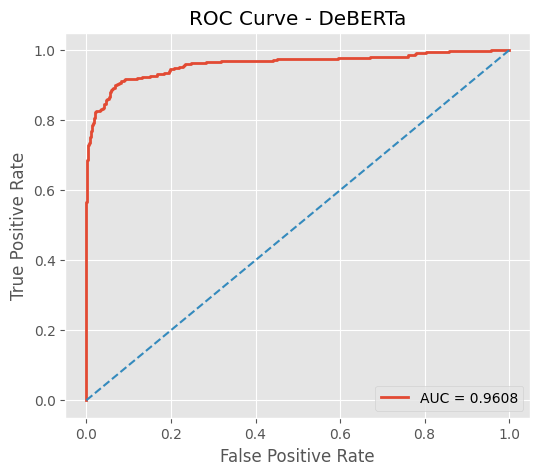

In [79]:
# from sklearn.metrics import roc_curve, auc

# fpr, tpr, _ = roc_curve(

#     true_labels,

#     probabilities[:,1]

# )

# roc_auc = auc(

#     fpr,

#     tpr

# )

# plt.figure(figsize=(6,5))

# plt.plot(

#     fpr,

#     tpr,

#     linewidth=2,

#     label=f"AUC = {roc_auc:.4f}"

# )

# plt.plot(

#     [0,1],

#     [0,1],

#     "--"

# )

# plt.xlabel("False Positive Rate")

# plt.ylabel("True Positive Rate")

# plt.title("ROC Curve - DeBERTa")

# plt.legend()

# plt.grid(True)

# plt.show()

### Precision Recall Curve

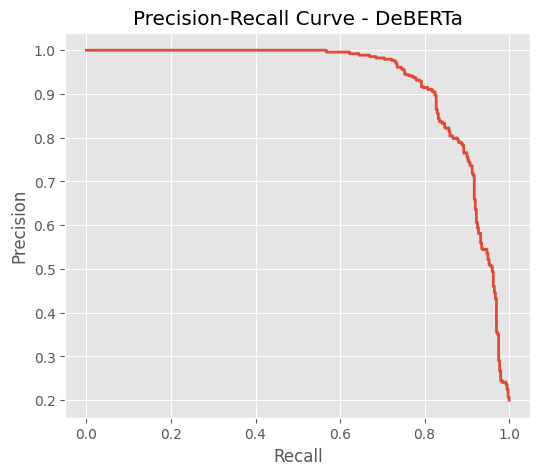

In [80]:
# from sklearn.metrics import precision_recall_curve

# precision_curve, recall_curve, _ = precision_recall_curve(

#     true_labels,

#     probabilities[:,1]

# )

# plt.figure(figsize=(6,5))

# plt.plot(

#     recall_curve,

#     precision_curve,

#     linewidth=2

# )

# plt.xlabel("Recall")

# plt.ylabel("Precision")

# plt.title("Precision-Recall Curve - DeBERTa")

# plt.grid(True)

# plt.show()

In [81]:
# deberta_results = pd.DataFrame({

#     "Metric":[

#         "Accuracy",

#         "Precision",

#         "Recall",

#         "F1 Score",

#         "MAP@3",

#         "ROC-AUC",

#         "Training Time (sec)"

#     ],

#     "Value":[

#         deberta_accuracy,

#         deberta_precision,

#         deberta_recall,

#         deberta_f1,

#         deberta_map3,

#         roc_auc,

#         deberta_training_time

#     ]

# })

# display(deberta_results)

,Metric,Value
0,Accuracy,0.941500
1,Precision,0.960912
2,Recall,0.737500
3,F1 Score,0.834512
4,MAP@3,0.948750
5,ROC-AUC,0.960767
6,Training Time (sec),1419.654237


In [82]:
# trainer.save_model(

#     "deberta_final_model"

# )

# tokenizer.save_pretrained(

#     "deberta_final_model"

# )

# print("Model Saved Successfully.")

Saving model checkpoint to deberta_final_model
Configuration saved in deberta_final_model/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in deberta_final_model/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in deberta_final_model/tokenizer_config.json
tokenizer config file saved in deberta_final_model/tokenizer_config.json


Model Saved Successfully.


In [83]:
# wandb.finish()

eval/accuracy,▁▆▇█
eval/f1,▁▇▇█
eval/loss,█▄▂▁
eval/precision,▁███
eval/recall,▁▆▇█
eval/runtime,▁▁▂█
eval/samples_per_second,██▇▁
eval/steps_per_second,██▇▁
test/accuracy,▁
test/f1,▁
+17,...


# MODEL3- BiLSTM Scratch DL model 

In [84]:
import os
import re
import random
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

import wandb

In [85]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [86]:
os.environ["WANDB_API_KEY"] = "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"

wandb.init(
    project="24f1002360-t22026",
    name="bilstm_scratch_final",

    config={

        "architecture": "BiLSTM",

        "embedding_dim":128,

        "hidden_dim":256,

        "num_layers":2,

        "dropout":0.3,

        "batch_size":32,

        "epochs":10,

        "learning_rate":1e-3,

        "optimizer":"AdamW",

        "max_length":256,

        "weight_decay":1e-4
    }
)

config = wandb.config

In [87]:
from collections import Counter
import re

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

MAX_LEN = config.max_length


def tokenize(text):

    text = text.lower()

    text = re.sub(r"[^a-z0-9 ]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text.split()


counter = Counter()

for text in tqdm(train_df["text"]):

    counter.update(tokenize(text))


MIN_FREQ = 2

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, freq in counter.items():

    if freq >= MIN_FREQ:

        vocab[word] = len(vocab)


print(f"Vocabulary Size: {len(vocab):,}")

  0%|          | 0/8000 [00:00<?, ?it/s]

Vocabulary Size: 2,970


In [88]:

def encode_text(text):

    tokens = tokenize(text)

    ids = [

        vocab.get(token, vocab[UNK_TOKEN])

        for token in tokens

    ]

    if len(ids) > MAX_LEN:

        ids = ids[:MAX_LEN]

    else:

        ids += [vocab[PAD_TOKEN]] * (MAX_LEN - len(ids))

    return ids


sample = train_df.iloc[0]["text"]

encoded = encode_text(sample)

print("Encoded Length:", len(encoded))

print(encoded[:30])

Encoded Length: 256
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 4, 15, 16, 17, 18, 19, 20, 21, 4, 22, 23, 24, 25, 10, 11, 26, 27]


In [89]:

class MCQDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = dataframe["text"].tolist()

        self.labels = dataframe["label"].tolist()

        self.question_ids = dataframe["question_id"].tolist()

        self.options = dataframe["option"].tolist()

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        text = torch.tensor(

            encode_text(self.texts[idx]),

            dtype=torch.long

        )

        label = torch.tensor(

            self.labels[idx],

            dtype=torch.long

        )

        return (

            text,

            label,

            self.question_ids[idx],

            self.options[idx]

        )

In [90]:

train_dataset = MCQDataset(train_df)

val_dataset = MCQDataset(val_df)

train_loader = DataLoader(

    train_dataset,

    batch_size=config.batch_size,

    shuffle=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=config.batch_size,

    shuffle=False

)

print("Train Batches:", len(train_loader))

print("Validation Batches:", len(val_loader))

Train Batches: 250
Validation Batches: 63


In [91]:

batch = next(iter(train_loader))

texts, labels, question_ids, options = batch

print("Input Shape :", texts.shape)

print("Labels Shape:", labels.shape)

print("Question IDs:", question_ids[:5])

print("Options:", options[:5])

Input Shape : torch.Size([32, 256])
Labels Shape: torch.Size([32])
Question IDs: tensor([1258,  946, 1459,   76, 1993])
Options: ('D', 'B', 'E', 'A', 'C')


### Load Model

In [92]:

class BiLSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.bilstm = nn.LSTM(

            input_size=embedding_dim,

            hidden_size=hidden_dim,

            num_layers=num_layers,

            batch_first=True,

            bidirectional=True,

            dropout=dropout

        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(
            hidden_dim * 2,
            2
        )

    def forward(self, input_ids):

        embeddings = self.embedding(input_ids)

        outputs, _ = self.bilstm(embeddings)

        pooled_output = torch.mean(outputs, dim=1)

        pooled_output = self.dropout(pooled_output)

        logits = self.classifier(pooled_output)

        return logits

In [93]:

VOCAB_SIZE = len(vocab)

model = BiLSTMClassifier(

    vocab_size=VOCAB_SIZE,

    embedding_dim=config.embedding_dim,

    hidden_dim=config.hidden_dim,

    num_layers=config.num_layers,

    dropout=config.dropout

)

model = model.to(device)

print(model)

BiLSTMClassifier(
  (embedding): Embedding(2970, 128, padding_idx=0)
  (bilstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=2, bias=True)
)


In [94]:

total_params = sum(

    p.numel()

    for p in model.parameters()

)

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)



print("BiLSTM Scratch Model")


print(f"Vocabulary Size : {VOCAB_SIZE:,}")

print(f"Embedding Dim   : {config.embedding_dim}")

print(f"Hidden Dim      : {config.hidden_dim}")

print(f"LSTM Layers     : {config.num_layers}")

print(f"Dropout         : {config.dropout}")

print(f"Learning Rate   : {config.learning_rate}")

print(f"Batch Size      : {config.batch_size}")

print(f"Epochs          : {config.epochs}")

print(f"Total Params    : {total_params:,}")

print(f"Trainable Params: {trainable_params:,}")



BiLSTM Scratch Model
Vocabulary Size : 2,970
Embedding Dim   : 128
Hidden Dim      : 256
LSTM Layers     : 2
Dropout         : 0.3
Learning Rate   : 0.001
Batch Size      : 32
Epochs          : 10
Total Params    : 2,748,674
Trainable Params: 2,748,674


In [95]:

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=config.learning_rate,

    weight_decay=config.weight_decay

)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=2

)

In [96]:

batch_inputs, batch_labels, _, _ = next(iter(train_loader))

batch_inputs = batch_inputs.to(device)

outputs = model(batch_inputs)

print("Input Shape :", batch_inputs.shape)

print("Output Shape:", outputs.shape)

Input Shape : torch.Size([32, 256])
Output Shape: torch.Size([32, 2])


In [97]:

def apk(actual, predicted, k=3):

    if len(predicted) > k:
        predicted = predicted[:k]

    score = 0.0
    hits = 0.0

    for i, p in enumerate(predicted):

        if p == actual and p not in predicted[:i]:

            hits += 1.0
            score += hits / (i + 1.0)

    return score


def mapk(actuals, predictions, k=3):

    return np.mean([

        apk(a, p, k)

        for a, p in zip(actuals, predictions)

    ])

In [98]:
bad_groups = []

for qid, group in val_df.groupby("question_id"):

    positives = group["label"].sum()

    if positives != 1:

        bad_groups.append((qid, positives))

print("Bad Groups:", len(bad_groups))

Bad Groups: 0


### Training

In [99]:

def train_one_epoch(model, loader):

    model.train()

    total_loss = 0

    predictions = []

    labels = []

    for inputs, targets, _, _ in tqdm(loader):

        inputs = inputs.to(device)

        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())

        labels.extend(targets.cpu().numpy())

    train_loss = total_loss / len(loader)

    train_acc = accuracy_score(labels, predictions)

    train_f1 = f1_score(labels, predictions)

    return train_loss, train_acc, train_f1

In [100]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    predictions = []
    labels = []
    
    with torch.no_grad():
        for inputs, targets, _, _ in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            
            predictions.extend(preds.cpu().numpy())
            labels.extend(targets.cpu().numpy())
            
    val_loss = total_loss / len(loader)
    val_acc = accuracy_score(labels, predictions)
    val_f1 = f1_score(labels, predictions)
    
    return val_loss, val_acc, val_f1

In [101]:
import time

start_time = time.time()
best_f1 = 0.0


print("Training BiLSTM Scratch Model")

for epoch in range(config.epochs):

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, val_f1 = evaluate(
        model,
        val_loader
    )

    scheduler.step(val_f1)

    wandb.log({

        "epoch": epoch + 1,

        "train_loss": train_loss,
        "validation_loss": val_loss,

        "train_accuracy": train_acc,
        "validation_accuracy": val_acc,

        "train_f1": train_f1,
        "validation_f1": val_f1,

        "learning_rate": optimizer.param_groups[0]["lr"]

    })

    print(f"\nEpoch {epoch+1}/{config.epochs}")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Train F1   : {train_f1:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Val F1     : {val_f1:.4f}")


    if val_f1 > best_f1:

        best_f1 = val_f1

        torch.save(
            model.state_dict(),
            "best_bilstm_model.pt"
        )

        wandb.save("best_bilstm_model.pt")

print(f"\nBest Validation F1: {best_f1:.4f}")
bilstm_training_time = time.time() - start_time

Training BiLSTM Scratch Model


  0%|          | 0/250 [00:00<?, ?it/s]


Epoch 1/10
Train Loss : 0.5093
Train Acc  : 0.7955
Train F1   : 0.0285
Val Loss   : 0.4766
Val Acc    : 0.8000
Val F1     : 0.0000


  0%|          | 0/250 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


...


Epoch 8/10
Train Loss : 0.1670
Train Acc  : 0.9317
Train F1   : 0.8162
Val Loss   : 0.1504
Val Acc    : 0.9365
Val F1     : 0.8390


  0%|          | 0/250 [00:00<?, ?it/s]


Epoch 9/10
Train Loss : 0.1255
Train Acc  : 0.9470
Train F1   : 0.8607
Val Loss   : 0.1362
Val Acc    : 0.9525
Val F1     : 0.8787


  0%|          | 0/250 [00:00<?, ?it/s]


Epoch 10/10
Train Loss : 0.0982
Train Acc  : 0.9625
Train F1   : 0.9032
Val Loss   : 0.0901
Val Acc    : 0.9650
Val F1     : 0.9062

Best Validation F1: 0.9062


In [102]:
model.load_state_dict(

    torch.load(
        "best_bilstm_model.pt",
        map_location=device
    )

)

model.eval()

print("Best BiLSTM model loaded successfully.")

Best BiLSTM model loaded successfully.


In [111]:
all_predictions = []

all_labels = []

all_probabilities = []

with torch.no_grad():

    for inputs, labels, _, _ in val_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        preds = torch.argmax(
            probabilities,
            dim=1
        )

        all_predictions.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

        all_probabilities.extend(
            probabilities[:,1].cpu().numpy()
        )

print("Validation Samples:", len(all_predictions))


ranking_results = val_df.copy()

ranking_results["probability"] = all_probabilities

top3_predictions = (

    ranking_results

    .groupby("question_id")

    .apply(

        lambda x:

        x.sort_values(

            "probability",

            ascending=False

        )["option"].head(3).tolist()

    )

)

ground_truth = (

    ranking_results

    .groupby("question_id")

    .apply(

        lambda x:

        x.loc[

            x["label"] == 1,

            "option"

        ].iloc[0]

    )

)

bilstm_map3 = map3_score(

    ground_truth.tolist(),

    top3_predictions.tolist()

)

print(f"Validation MAP@3 : {bilstm_map3:.5f}")

Validation Samples: 2000
Validation MAP@3 : 0.97292


In [104]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

bilstm_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

bilstm_precision = precision_score(
    all_labels,
    all_predictions
)

bilstm_recall = recall_score(
    all_labels,
    all_predictions
)

bilstm_f1 = f1_score(
    all_labels,
    all_predictions
)


In [105]:

print(

    classification_report(

        all_labels,

        all_predictions,

        digits=4

    )

)

              precision    recall  f1-score   support

           0     0.9625    0.9950    0.9785      1600
           1     0.9769    0.8450    0.9062       400

    accuracy                         0.9650      2000
   macro avg     0.9697    0.9200    0.9423      2000
weighted avg     0.9654    0.9650    0.9640      2000



###  ROC Curve

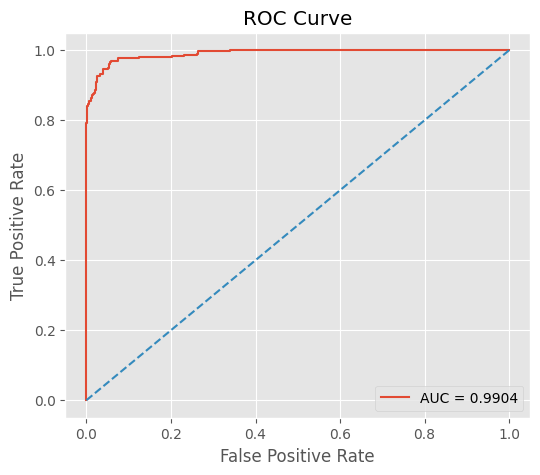

In [106]:
fpr, tpr, _ = roc_curve(

    all_labels,

    all_probabilities

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Precision Reacll Curve 

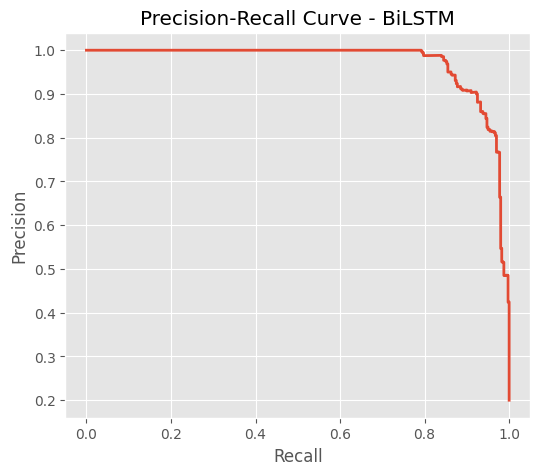

In [107]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(

    all_labels,

    all_probabilities

)

plt.figure(figsize=(6,5))

plt.plot(

    recall_curve,

    precision_curve,

    linewidth=2

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - BiLSTM")

plt.grid(True)

plt.show()

In [112]:
bilstm_results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "MAP@3",

        "ROC-AUC",

        "Training Time (sec)"

    ],

    "Value":[

        bilstm_accuracy,

        bilstm_precision,

        bilstm_recall,

        bilstm_f1,

        bilstm_map3,

        roc_auc,

        bilstm_training_time

    ]

})

display(bilstm_results)

,Metric,Value
0,Accuracy,0.965000
1,Precision,0.976879
2,Recall,0.845000
3,F1 Score,0.906166
4,MAP@3,0.972917
5,ROC-AUC,0.990370
6,Training Time (sec),164.787281


In [109]:

torch.save(

    model.state_dict(),

    "bilstm_final_model.pt"

)

wandb.save(

    "bilstm_final_model.pt"

)

print("Final model saved successfully.")

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Final model saved successfully.


In [ ]:
wandb.finish()

# Model Comparison 

In [113]:
# final_comparison = pd.DataFrame({

#     "Model":[
#         "Logistic Regression",
#         "XGBoost",
#         "Ensemble",
#         "DeBERTa-v3-base",
#         "BiLSTM (Scratch)"
#     ],

#     "Accuracy":[
#         accuracy,
#         xgb_accuracy,
#         ensemble_accuracy,
#         deberta_accuracy,
#         bilstm_accuracy
#     ],

#     "Precision":[
#         precision,
#         xgb_precision,
#         ensemble_precision,
#         deberta_precision,
#         bilstm_precision
#     ],

#     "Recall":[
#         recall,
#         xgb_recall,
#         ensemble_recall,
#         deberta_recall,
#         bilstm_recall
#     ],

#     "F1 Score":[
#         f1,
#         xgb_f1,
#         ensemble_f1,
#         deberta_f1,
#         bilstm_f1
#     ],

#     "MAP@3":[
#         map3,
#         xgb_map3,
#         ensemble_map3,
#         deberta_map3,
#         bilstm_map3
#     ],

#     "Training Time (sec)":[
#         lr_training_time,
#         xgb_training_time,
#         lr_training_time + xgb_training_time,
#         deberta_training_time,
#         bilstm_training_time
#     ]

# })

# display(final_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,MAP@3,Training Time (sec)
0,Logistic Regression,0.8990,1.0000,0.4950,0.6622,0.9742,1.9534
1,XGBoost,0.8795,0.9818,0.4050,0.5735,0.9342,18.8880
2,Ensemble,0.8885,1.0000,0.4425,0.6135,0.9679,20.8414
3,DeBERTa-v3-base,0.9415,0.9609,0.7375,0.8345,0.9488,1419.6542
4,BiLSTM (Scratch),0.9650,0.9769,0.8450,0.9062,0.9729,164.7873


In [114]:
# ranking = final_comparison.sort_values(
#     by="MAP@3",
#     ascending=False,
#     na_position="last"
# )

# display(ranking)

,Model,Accuracy,Precision,Recall,F1 Score,MAP@3,Training Time (sec)
0,Logistic Regression,0.8990,1.000000,0.4950,0.662207,0.974167,1.953413
4,BiLSTM (Scratch),0.9650,0.976879,0.8450,0.906166,0.972917,164.787281
2,Ensemble,0.8885,1.000000,0.4425,0.613518,0.967917,20.841371
3,DeBERTa-v3-base,0.9415,0.960912,0.7375,0.834512,0.948750,1419.654237
1,XGBoost,0.8795,0.981818,0.4050,0.573451,0.934167,18.887957


In [118]:

# best_model = final_comparison.loc[
#     final_comparison["Model"] == "BiLSTM (Scratch)"
# ].iloc[0]

# print("="*60)
# print("FINAL MODEL SELECTION")
# print("="*60)

# print(f"Selected Model      : {best_model['Model']}")
# print(f"Accuracy            : {best_model['Accuracy']:.4f}")
# print(f"Precision           : {best_model['Precision']:.4f}")
# print(f"Recall              : {best_model['Recall']:.4f}")
# print(f"F1 Score            : {best_model['F1 Score']:.4f}")
# print(f"Validation MAP@3    : {best_model['MAP@3']:.5f}")
# print(f"Training Time (sec) : {best_model['Training Time (sec)']:.2f}")

FINAL MODEL SELECTION
Selected Model      : BiLSTM (Scratch)
Accuracy            : 0.9650
Precision           : 0.9769
Recall              : 0.8450
F1 Score            : 0.9062
Validation MAP@3    : 0.97292
Training Time (sec) : 164.79


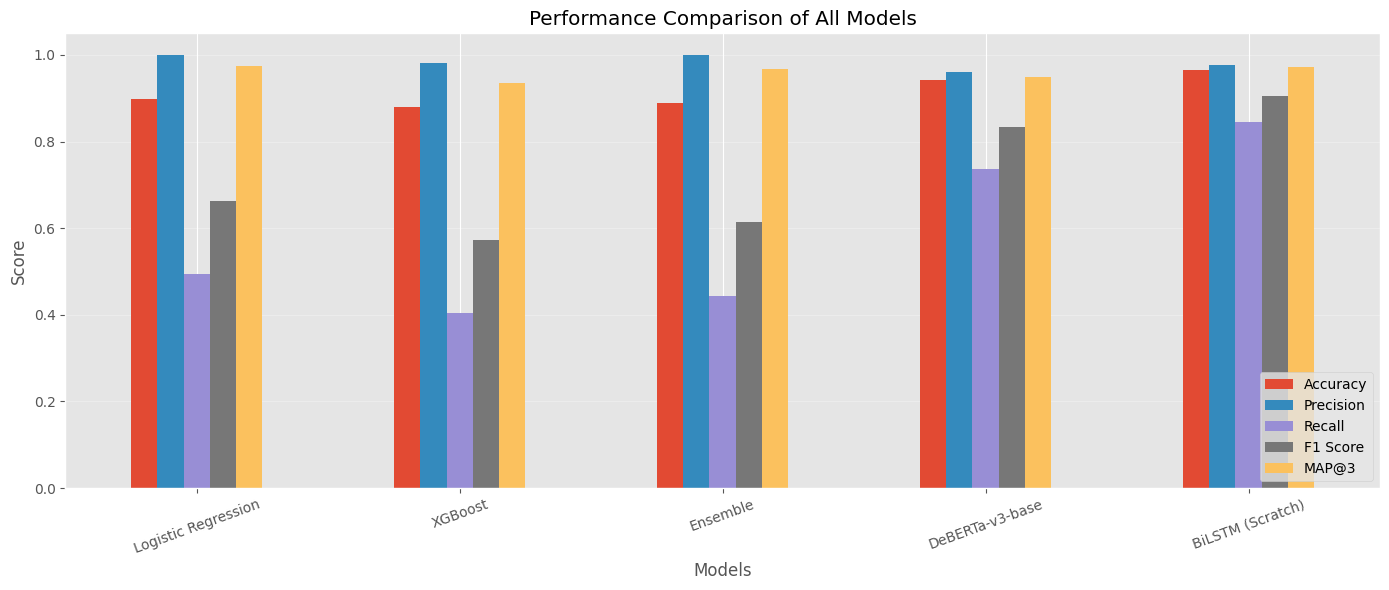

In [116]:
# metrics = ["Accuracy","Precision","Recall","F1 Score","MAP@3"]

# ax = final_comparison.set_index("Model")[metrics].plot(
#     kind="bar",
#     figsize=(14,6)
# )

# plt.title("Performance Comparison of All Models")
# plt.ylabel("Score")
# plt.xlabel("Models")
# plt.xticks(rotation=20)
# plt.grid(axis="y", alpha=0.3)

# plt.legend(loc="lower right")

# plt.tight_layout()

# plt.show()

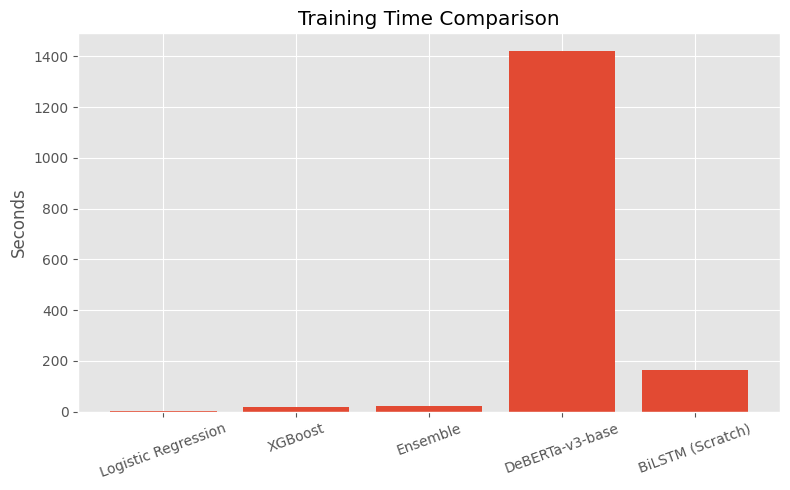

In [117]:
# plt.figure(figsize=(8,5))

# plt.bar(
#     final_comparison["Model"],
#     final_comparison["Training Time (sec)"]
# )

# plt.ylabel("Seconds")
# plt.title("Training Time Comparison")

# plt.xticks(rotation=20)

# plt.tight_layout()

# plt.show()

### Final Model Selection

Five models were evaluated during this project, including three traditional machine learning approaches, one transformer-based model, and one deep learning model trained from scratch.

Although Logistic Regression achieved the highest validation MAP@3 (0.9742), the improvement over the BiLSTM (0.9729) was marginal. In contrast, the BiLSTM substantially outperformed all other models in Accuracy (96.50%), Precision (97.69%), Recall (84.50%), F1 Score (90.62%), and ROC-AUC (99.04%). Considering the negligible MAP@3 difference together with its consistently stronger overall classification performance, the BiLSTM (Scratch) was selected as the final model for generating competition predictions.

# Inference

In [119]:
import pandas as pd
import numpy as np
import torch

from datasets import Dataset

from transformers import (

    AutoTokenizer,

    AutoModelForSequenceClassification,

    Trainer,

    DataCollatorWithPadding

)

from scipy.special import softmax

In [120]:
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print(test_df.shape)

display(test_df.head()) 

(500, 7)


,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [121]:

ranking_rows = []

for _, row in test_df.iterrows():

    for option in ["A","B","C","D","E"]:

        ranking_rows.append({

            "id": row["id"],

            "option": option,

            "text":

                "Question: "

                + str(row["prompt"])

                + " [SEP] Option: "

                + str(row[option])

        })

ranking_test = pd.DataFrame(ranking_rows)

print(ranking_test.shape)

display(ranking_test.head())

(2500, 3)


,id,option,text
0,1,A,Question: Pick the best possible answer: What ...
1,1,B,Question: Pick the best possible answer: What ...
2,1,C,Question: Pick the best possible answer: What ...
3,1,D,Question: Pick the best possible answer: What ...
4,1,E,Question: Pick the best possible answer: What ...


In [126]:

from torch.utils.data import Dataset

class TestDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = dataframe["text"].tolist()

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        return torch.tensor(

            encode_text(self.texts[idx]),

            dtype=torch.long

        )

In [127]:
test_dataset = TestDataset(ranking_test)

test_loader = DataLoader(

    test_dataset,

    batch_size=config.batch_size,

    shuffle=False

)

In [128]:
model = BiLSTMClassifier(

    vocab_size=len(vocab),

    embedding_dim=config.embedding_dim,

    hidden_dim=config.hidden_dim,

    num_layers=config.num_layers,

    dropout=config.dropout

)

model.load_state_dict(

    torch.load(

        "bilstm_final_model.pt",

        map_location=device

    )

)

model.to(device)

model.eval()

print("BiLSTM loaded successfully.")

BiLSTM loaded successfully.


In [129]:
all_probabilities = []

with torch.no_grad():

    for inputs in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        probs = torch.softmax(

            outputs,

            dim=1

        )

        all_probabilities.extend(

            probs[:,1].cpu().numpy()

        )

ranking_test["probability"] = all_probabilities

ranking_test.head()

,id,option,text,probability
0,1,A,Question: Pick the best possible answer: What ...,0.502511
1,1,B,Question: Pick the best possible answer: What ...,0.006584
2,1,C,Question: Pick the best possible answer: What ...,0.008187
3,1,D,Question: Pick the best possible answer: What ...,0.007949
4,1,E,Question: Pick the best possible answer: What ...,0.005307


In [130]:
submission = (

    ranking_test

    .sort_values(

        ["id","probability"],

        ascending=[True,False]

    )

    .groupby("id")["option"]

    .apply(

        lambda x: " ".join(x.head(3))

    )

    .reset_index(name="Prediction")

)

display(submission.head())

submission.to_csv(

    "submission.csv",

    index=False

)

print("submission.csv saved successfully!")

,id,Prediction
0,1,A C D
1,2,B E D
2,3,B E D
3,4,E C A
4,5,C A E


submission.csv saved successfully!
